Import Libraries

In [1]:
!pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn — dataset, model, utilities
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

Loading the data

In [4]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns = iris.feature_names)

df['species'] = iris.target

df['species_name'] = df['species'].map({
    0: 'sentosa',
    1: 'versicolor',
    2: 'virginica'
})

print("Dataset loaded.")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset loaded.
Shape: (150, 6)
Columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species', 'species_name']


First 5 rows

In [5]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,sentosa
1,4.9,3.0,1.4,0.2,0,sentosa
2,4.7,3.2,1.3,0.2,0,sentosa
3,4.6,3.1,1.5,0.2,0,sentosa
4,5.0,3.6,1.4,0.2,0,sentosa


In [6]:
print("Data types:")
print(df.dtypes)
print()
print("Class distribution:")
print(df['species_name'].value_counts())

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name          object
dtype: object

Class distribution:
species_name
sentosa       50
versicolor    50
virginica     50
Name: count, dtype: int64


Clean Data

In [7]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Total missing: 0


In [8]:
dups = df.duplicated().sum()
print(f"Duplicate rows: {dups}")

if dups > 0:
    df = df.drop_duplicates()
    print(f"Removed {dups} duplicates.")
    print(f"New shape: {df.shape}")
else:
    print("No duplicates found.")

Duplicate rows: 1
Removed 1 duplicates.
New shape: (149, 6)


In [9]:
print("Summary statistics:")
print(df.describe().round(2))

Summary statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             149.00            149.00             149.00   
mean                5.84              3.06               3.75   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.30   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       petal width (cm)  species  
count            149.00   149.00  
mean               1.19     0.99  
std                0.76     0.82  
min                0.10     0.00  
25%                0.30     0.00  
50%                1.30     1.00  
75%                1.80     2.00  
max                2.50     2.00  


In [10]:
feature_cols = [
    'sepal length (cm)', 'sepal width (cm)',
    'petal length (cm)', 'petal width (cm)'
]

print("Outlier detection — IQR method")
print("=" * 40)
for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\n{col}")
    print(f"  Bounds: {lower:.2f} – {upper:.2f}")
    print(f"  Outliers found: {len(outliers)}")

Outlier detection — IQR method

sepal length (cm)
  Bounds: 3.15 – 8.35
  Outliers found: 0

sepal width (cm)
  Bounds: 2.05 – 4.05
  Outliers found: 4

petal length (cm)
  Bounds: -3.65 – 10.35
  Outliers found: 0

petal width (cm)
  Bounds: -1.95 – 4.05
  Outliers found: 0


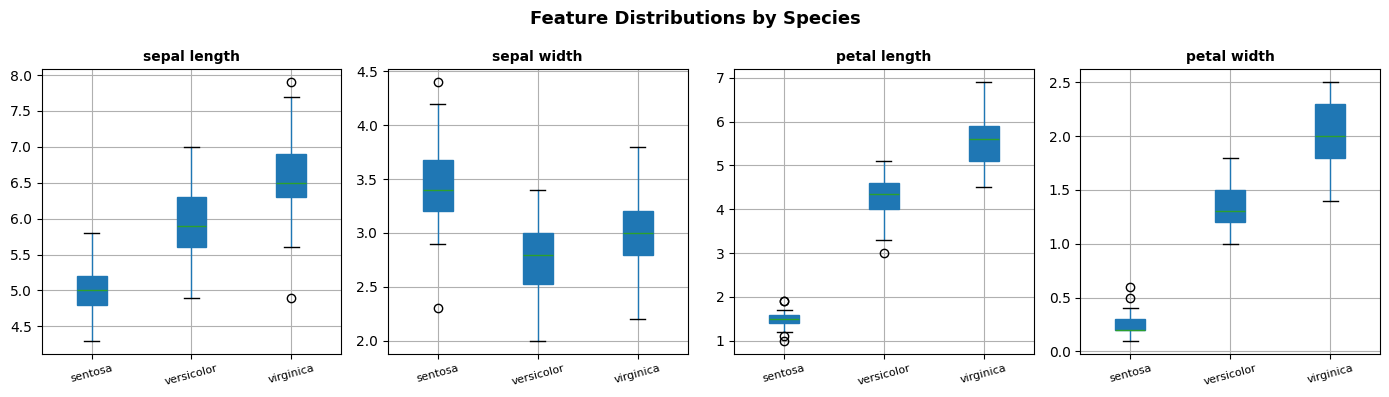

Chart saved.


In [11]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
fig.suptitle('Feature Distributions by Species',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes, feature_cols):
    df.boxplot(column=col, by='species_name',
               ax=ax, patch_artist=True)
    ax.set_title(col.replace(' (cm)', ''),
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    plt.sca(ax)
    plt.xticks(rotation=15, fontsize=8)

plt.suptitle('Feature Distributions by Species',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_iris.png', dpi=150)
plt.show()
print("Chart saved.")

In [12]:
df = df.reset_index(drop=True)
print(f"Final clean dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print("Ready for training.")

Final clean dataset: 149 rows, 6 columns
Ready for training.


Train datasets

In [13]:
X = df[feature_cols]   # 4 feature columns
y = df['species']      # target: 0, 1, 2

print(f"Features (X): {X.shape}")
print(f"Target   (y): {y.shape}")
print(f"Classes: {list(y.unique())}  -> 0=setosa, 1=versicolor, 2=virginica")

Features (X): (149, 4)
Target   (y): (149,)
Classes: [np.int64(0), np.int64(1), np.int64(2)]  -> 0=setosa, 1=versicolor, 2=virginica


In [14]:
#split into test and train
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42,     # reproducible results
    stratify=y           # keep class proportions equal
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")

Training set : 119 samples
Test set     : 30 samples


In [15]:
# SVM is sensitive to feature scale — always scale first
scaler = StandardScaler()

# Fit on training data ONLY, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled.")
print(f"Train mean after scaling: {X_train_scaled.mean():.4f}")
print(f"Train std  after scaling: {X_train_scaled.std():.4f}")

Features scaled.
Train mean after scaling: 0.0000
Train std  after scaling: 1.0000


In [16]:
# RBF kernel is the most common choice for classification
svm_model = SVC(
    kernel='rbf',    # Radial Basis Function kernel
    C=1.0,           # regularisation — higher = tighter fit
    gamma='scale',   # kernel coefficient (auto-calculated)
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

print("SVM model trained.")
print(f"Kernel     : {svm_model.kernel}")
print(f"C          : {svm_model.C}")
print(f"n_support  : {svm_model.n_support_}  (support vectors per class)")

SVM model trained.
Kernel     : rbf
C          : 1.0
n_support  : [ 7 18 18]  (support vectors per class)


Predictions

In [17]:
y_pred = svm_model.predict(X_test_scaled)

print("Predictions:")
print(y_pred)
print()
print("Actual values:")
print(y_test.values)

Predictions:
[1 1 2 0 2 1 1 0 2 2 0 0 0 1 2 0 2 0 2 0 1 2 0 0 1 1 2 2 2 1]

Actual values:
[1 1 2 0 2 1 1 0 2 2 0 0 0 1 2 0 1 0 2 0 1 2 0 0 1 1 2 2 2 1]


In [18]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 96.67%


In [20]:
target_names = ['setosa', 'versicolor', 'virginica']

print("Classification Report:")
print(classification_report(y_test, y_pred,
                             target_names=target_names))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



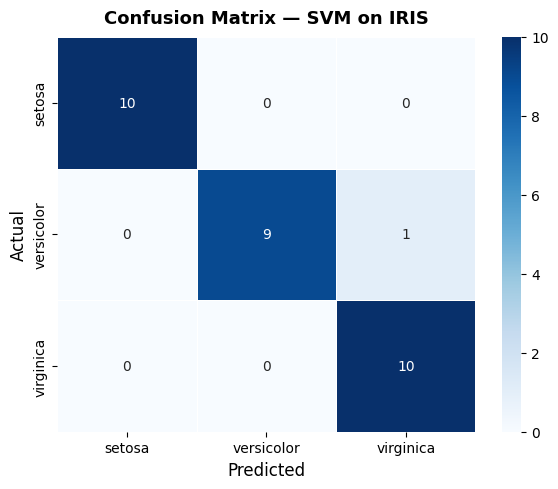

Saved: confusion_matrix.png


In [21]:
cm = confusion_matrix(y_test, y_pred)
target_names = ['setosa', 'versicolor', 'virginica']

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    linewidths=0.5,
    ax=ax
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual',    fontsize=12)
ax.set_title('Confusion Matrix — SVM on IRIS',
             fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

In [23]:
# Colour map — one colour per species
colors = {
    0: '#E84855',   # setosa     → red
    1: '#1C7293',   # versicolor → blue
    2: '#3BB273'    # virginica  → green
}
species_labels = {
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
}

# Feature column names (short labels for axis)
feature_cols = [
    'sepal length (cm)',
    'sepal width (cm)',
    'petal length (cm)',
    'petal width (cm)'
]

print("Setup complete. Ready to plot.")

Setup complete. Ready to plot.


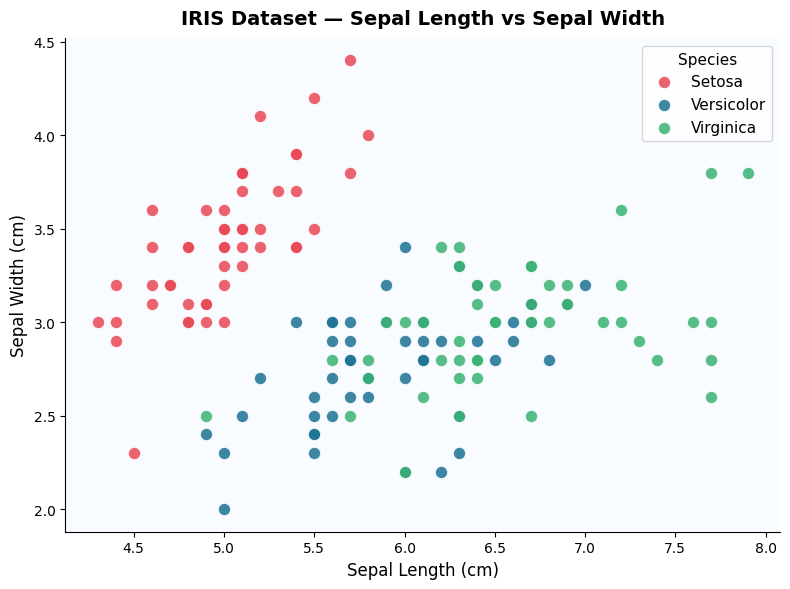

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))

for species_id, label in species_labels.items():
    mask = df['species'] == species_id
    ax.scatter(
        df.loc[mask, 'sepal length (cm)'],
        df.loc[mask, 'sepal width (cm)'],
        c=colors[species_id],
        label=label,
        s=80,
        edgecolors='white',
        linewidth=0.8,
        alpha=0.85
    )

ax.set_xlabel('Sepal Length (cm)', fontsize=12)
ax.set_ylabel('Sepal Width (cm)',  fontsize=12)
ax.set_title('IRIS Dataset — Sepal Length vs Sepal Width',
             fontsize=14, fontweight='bold', pad=10)
ax.legend(title='Species', fontsize=11, title_fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('#F8FBFF')

plt.tight_layout()
plt.savefig('scatter_sepal.png', dpi=150)
plt.show()

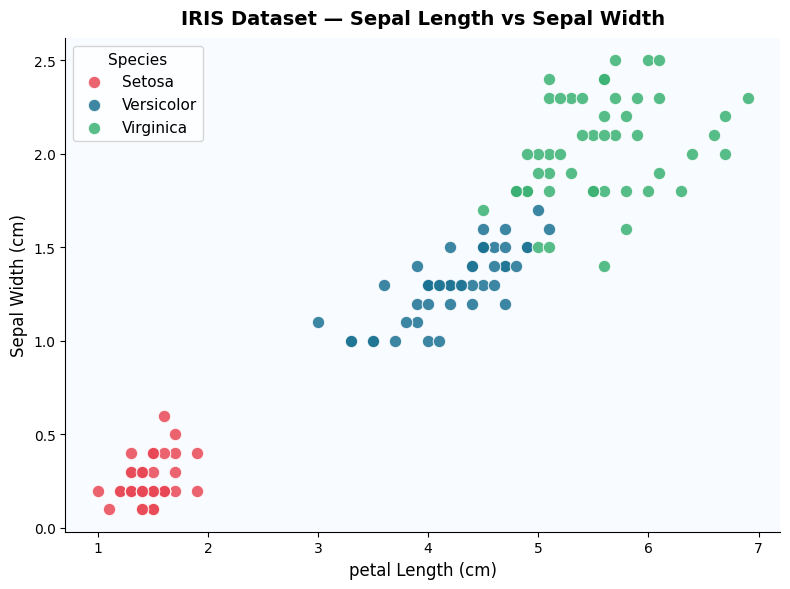

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

for species_id, label in species_labels.items():
    mask = df['species'] == species_id
    ax.scatter(
        df.loc[mask, 'petal length (cm)'],
        df.loc[mask, 'petal width (cm)'],
        c=colors[species_id],
        label=label,
        s=80,
        edgecolors='white',
        linewidth=0.8,
        alpha=0.85
    )

ax.set_xlabel('petal Length (cm)', fontsize=12)
ax.set_ylabel('petal Width (cm)',  fontsize=12)
ax.set_title('IRIS Dataset — Petal Length vs Petal Width',
             fontsize=14, fontweight='bold', pad=10)
ax.legend(title='Species', fontsize=11, title_fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.set_facecolor('#F8FBFF')

plt.tight_layout()
plt.show()